# Optimasi Warna dan Kontras Gambar Bawah Air
## Knowledge Distillation: FUnIE-GAN (Teacher) → MobileNetV3-Small Generator (Student)

**Pipeline:**
```
RGB Images (SeaThru Dataset)
      ↓
Preprocessing (Resize, Normalize, Augment)
      ↓
Training Teacher: FUnIE-GAN
      ↓
Knowledge Distillation → Student: MobileNetV3-Small Generator
      ↓
Evaluasi (PSNR, SSIM, UIQM, FPS)
      ↓
Visualisasi Before/After
```

## Cell 1: Install & Import

In [1]:
# Install dependencies
!pip install -q scikit-image seaborn torchsummary

import os
import random
import time
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Device: cuda
GPU: Tesla T4


## Cell 2: Load Dataset Paths

In [2]:
DATASET_PATH = "/kaggle/input/datasets/colorlabeilat/seathru-dataset"
IMG_SIZE = 256  # resize target

image_paths = []
for i in range(1, 6):
    folder_path = os.path.join(DATASET_PATH, f"D{i}", f"D{i}", "linearPNG")
    images = glob(os.path.join(folder_path, "*.png"))
    images += glob(os.path.join(folder_path, "*.jpg"))
    image_paths.extend(images)

# Filter: RGB only (exclude depth maps)
def is_rgb(path):
    try:
        img = Image.open(path)
        return img.mode in ('RGB', 'RGBA') and min(img.size) >= 64
    except:
        return False

image_paths = [p for p in image_paths if is_rgb(p)]
print(f'Total RGB images: {len(image_paths)}')

# Dataset statistics
for i in range(1, 6):
    count = sum(1 for p in image_paths if f'/D{i}/' in p)
    print(f'  D{i}: {count} images')

Total RGB images: 1216
  D1: 633 images
  D2: 319 images
  D3: 68 images
  D4: 153 images
  D5: 43 images


## Cell 3: Preprocessing & Dataset Class

In [3]:
class UnderwaterDataset(Dataset):
    """
    Dataset untuk gambar bawah air.
    - Input  (degraded): gambar asli bawah air (warna hijau/biru, kontras rendah)
    - Target (enhanced): versi yang sudah diproses white-balance sederhana
                         sebagai pseudo ground-truth saat GT tidak tersedia
    """
    def __init__(self, paths, img_size=256, augment=False):
        self.paths   = paths
        self.size    = img_size
        self.augment = augment

        # Normalisasi standar ImageNet (sesuai paper FUnIE-GAN)
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.paths)

    def _white_balance_pseudo_gt(self, img_np):
        """Gray-world white balance sebagai pseudo GT sederhana."""
        img_f = img_np.astype(np.float32)
        means = img_f.mean(axis=(0, 1))
        gray  = means.mean()
        scale = gray / (means + 1e-8)
        out   = np.clip(img_f * scale, 0, 255).astype(np.uint8)
        return out

    def _augment(self, inp, tgt):
        """Augmentasi simetris: input & target mendapat transformasi yang sama."""
        # Random horizontal flip
        if random.random() > 0.5:
            inp = TF.hflip(inp)
            tgt = TF.hflip(tgt)
        # Random vertical flip
        if random.random() > 0.5:
            inp = TF.vflip(inp)
            tgt = TF.vflip(tgt)
        # Random rotation ±10°
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            inp   = TF.rotate(inp, angle)
            tgt   = TF.rotate(tgt, angle)
        # Random crop & resize (zoom 80–100%)
        if random.random() > 0.5:
            i, j, h, w = T.RandomResizedCrop.get_params(
                inp, scale=(0.8, 1.0), ratio=(0.9, 1.1))
            inp = TF.resized_crop(inp, i, j, h, w, (self.size, self.size))
            tgt = TF.resized_crop(tgt, i, j, h, w, (self.size, self.size))
        # Color jitter hanya pada input (simulasi variasi degradasi)
        if random.random() > 0.5:
            inp = TF.adjust_brightness(inp, random.uniform(0.85, 1.15))
            inp = TF.adjust_contrast(inp,   random.uniform(0.85, 1.15))
        return inp, tgt

    def __getitem__(self, idx):
        img_np = np.array(Image.open(self.paths[idx]).convert('RGB'))

        # Pseudo GT
        tgt_np = self._white_balance_pseudo_gt(img_np)

        # PIL untuk augmentasi TF
        inp_pil = Image.fromarray(img_np).resize((self.size, self.size), Image.LANCZOS)
        tgt_pil = Image.fromarray(tgt_np).resize((self.size, self.size), Image.LANCZOS)

        if self.augment:
            inp_pil, tgt_pil = self._augment(inp_pil, tgt_pil)

        # ToTensor → [0,1] lalu normalize
        to_tensor = T.ToTensor()
        inp_t = self.normalize(to_tensor(inp_pil))
        tgt_t = self.normalize(to_tensor(tgt_pil))

        return inp_t, tgt_t


# ── Train / Val / Test split 80 / 10 / 10 ──
random.shuffle(image_paths)
n     = len(image_paths)
n_tr  = int(0.8 * n)
n_val = int(0.1 * n)

train_paths = image_paths[:n_tr]
val_paths   = image_paths[n_tr:n_tr + n_val]
test_paths  = image_paths[n_tr + n_val:]

print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

BATCH_SIZE = 16

train_ds = UnderwaterDataset(train_paths, IMG_SIZE, augment=True)
val_ds   = UnderwaterDataset(val_paths,   IMG_SIZE, augment=False)
test_ds  = UnderwaterDataset(test_paths,  IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 972 | Val: 121 | Test: 123
Train batches: 61 | Val batches: 8


## Cell 4: Visualisasi Sample + Augmentasi

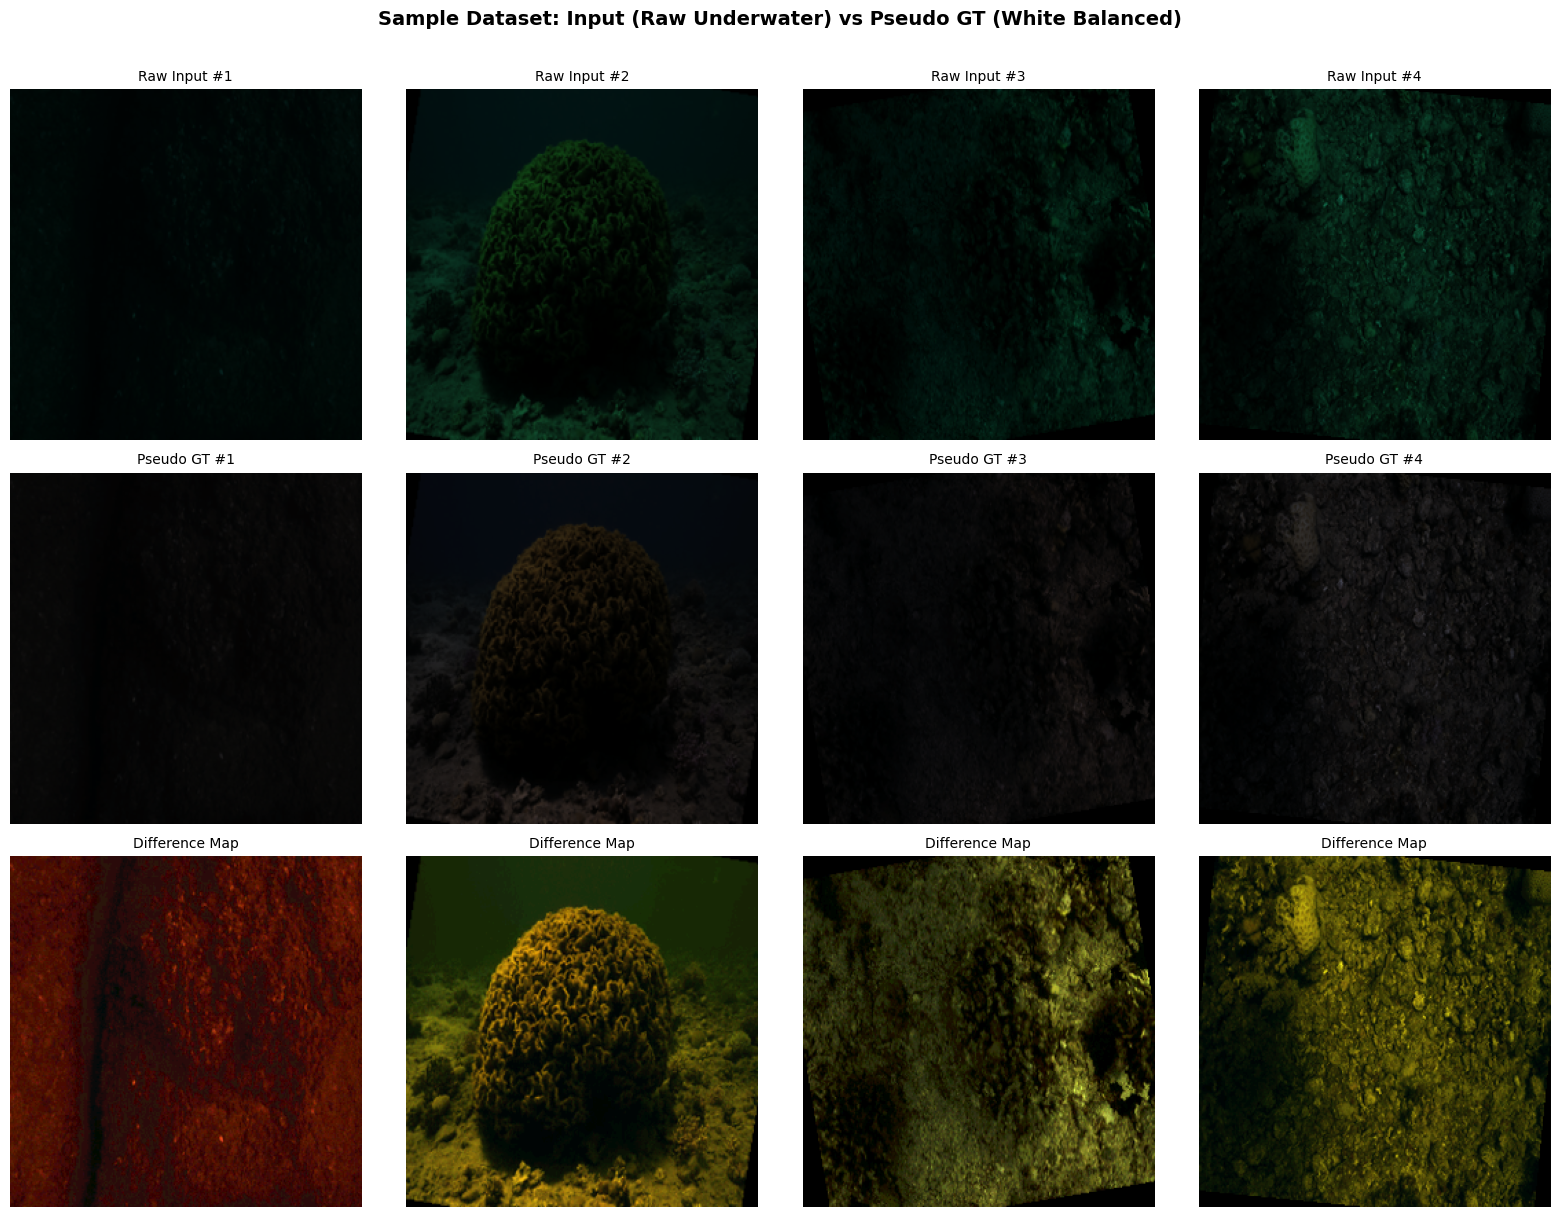

In [4]:
def denormalize(t):
    """Kembalikan tensor normalized ke [0,1] untuk visualisasi."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(t * std + mean, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Dataset: Input (Raw Underwater) vs Pseudo GT (White Balanced)',
             fontsize=14, fontweight='bold', y=1.01)

for col in range(4):
    inp, tgt = train_ds[col * 30]
    axes[0, col].imshow(denormalize(inp).permute(1,2,0).numpy())
    axes[0, col].set_title(f'Raw Input #{col+1}', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(denormalize(tgt).permute(1,2,0).numpy())
    axes[1, col].set_title(f'Pseudo GT #{col+1}', fontsize=10)
    axes[1, col].axis('off')

    diff = (denormalize(tgt) - denormalize(inp)).abs().permute(1,2,0).numpy()
    axes[2, col].imshow(diff / diff.max())
    axes[2, col].set_title(f'Difference Map', fontsize=10)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('sample_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5: Teacher Model — FUnIE-GAN

In [5]:
# ─────────────────────────────────────────────
# FUnIE-GAN Generator (U-Net style)
# Paper: Islam et al., 2020
# ─────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=0.0):
        super().__init__()
        if down:
            conv = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=not use_bn)
        else:
            conv = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=not use_bn)
        layers = [conv]
        if use_bn: layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        if dropout > 0: layers.append(nn.Dropout(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class FUnIEGANGenerator(nn.Module):
    """FUnIE-GAN U-Net Generator (Teacher)."""
    def __init__(self):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3,   64,  down=True, use_bn=False)
        self.e2 = ConvBlock(64,  128, down=True)
        self.e3 = ConvBlock(128, 256, down=True)
        self.e4 = ConvBlock(256, 512, down=True)
        self.e5 = ConvBlock(512, 512, down=True)
        # Bottleneck
        self.e6 = ConvBlock(512, 512, down=True, use_bn=False)
        # Decoder (skip connections)
        self.d1 = ConvBlock(512,       512, down=False, dropout=0.5)
        self.d2 = ConvBlock(512 + 512, 512, down=False, dropout=0.5)
        self.d3 = ConvBlock(512 + 512, 256, down=False)
        self.d4 = ConvBlock(256 + 256, 128, down=False)
        self.d5 = ConvBlock(128 + 128, 64,  down=False)
        self.out = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        d1 = self.d1(e6)
        d2 = self.d2(torch.cat([d1, e5], 1))
        d3 = self.d3(torch.cat([d2, e4], 1))
        d4 = self.d4(torch.cat([d3, e3], 1))
        d5 = self.d5(torch.cat([d4, e2], 1))
        return self.out(torch.cat([d5, e1], 1))


class PatchGANDiscriminator(nn.Module):
    """PatchGAN Discriminator (70×70 receptive field)."""
    def __init__(self):
        super().__init__()
        def block(ic, oc, bn=True):
            layers = [nn.Conv2d(ic, oc, 4, 2, 1, bias=not bn)]
            if bn: layers.append(nn.BatchNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.model = nn.Sequential(
            *block(6, 64, bn=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, img_a, img_b):
        return self.model(torch.cat([img_a, img_b], 1))


teacher_G = FUnIEGANGenerator().to(DEVICE)
teacher_D = PatchGANDiscriminator().to(DEVICE)

params_G = sum(p.numel() for p in teacher_G.parameters()) / 1e6
params_D = sum(p.numel() for p in teacher_D.parameters()) / 1e6
print(f'Teacher Generator params: {params_G:.2f}M')
print(f'Teacher Discriminator params: {params_D:.2f}M')

Teacher Generator params: 29.24M
Teacher Discriminator params: 0.67M


## Cell 6: Student Model — MobileNetV3-Small Generator

In [6]:
# ─────────────────────────────────────────────
# MobileNetV3-Small Generator (Student)
# Menggunakan Depthwise Separable Convolution
# untuk efisiensi ekstrem (target: Raspberry Pi / Micro-AUV)
# ─────────────────────────────────────────────
class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Conv: depthwise + pointwise."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.Hardswish()

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block (dari MobileNetV3)."""
    def __init__(self, ch, r=4):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, ch // r),
            nn.ReLU(),
            nn.Linear(ch // r, ch),
            nn.Hardsigmoid()
        )

    def forward(self, x):
        return x * self.se(x).view(x.shape[0], -1, 1, 1)


class MobileUNetStudent(nn.Module):
    """
    Lightweight U-Net dengan MobileNetV3-Small backbone.
    Encoder: Depthwise Separable Conv + SE blocks.
    Decoder: Bilinear upsample + DW-Sep Conv (lebih efisien dari transposed conv).
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1, bias=False),
            nn.BatchNorm2d(16), nn.Hardswish()          # 128×128
        )
        self.enc2 = nn.Sequential(
            DepthwiseSeparableConv(16, 24, stride=2),   # 64×64
            SEBlock(24)
        )
        self.enc3 = nn.Sequential(
            DepthwiseSeparableConv(24, 40, stride=2),   # 32×32
            SEBlock(40)
        )
        self.enc4 = nn.Sequential(
            DepthwiseSeparableConv(40, 80, stride=2),   # 16×16
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            DepthwiseSeparableConv(80, 96, stride=2),   # 8×8
            SEBlock(96)
        )
        # Decoder (bilinear + DW-Sep)
        self.dec4 = DepthwiseSeparableConv(96 + 80, 80)
        self.dec3 = DepthwiseSeparableConv(80 + 40, 40)
        self.dec2 = DepthwiseSeparableConv(40 + 24, 24)
        self.dec1 = DepthwiseSeparableConv(24 + 16, 16)
        self.out  = nn.Sequential(
            nn.Conv2d(16, 3, 1),
            nn.Tanh()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b  = self.bottleneck(e4)

        d4 = F.interpolate(b,  scale_factor=2, mode='bilinear', align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], 1))
        d3 = F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], 1))
        out = F.interpolate(d1, scale_factor=2, mode='bilinear', align_corners=False)
        return self.out(out)


student = MobileUNetStudent().to(DEVICE)
params_S = sum(p.numel() for p in student.parameters()) / 1e6
print(f'Student params: {params_S:.2f}M')
print(f'Compression ratio: {params_G / params_S:.1f}x lebih ringan dari Teacher')

Student params: 0.05M
Compression ratio: 642.3x lebih ringan dari Teacher


## Cell 7: Loss Functions

In [7]:
import torchvision.models as models

class MobileNetV2PerceptualLoss(nn.Module):
    """
    Perceptual loss menggunakan MobileNetV2 intermediate features.

    Mengapa MobileNetV2 vs VGG16?
    ─────────────────────────────
    • VGG16   : 138M parameter, 15 GB VRAM peak, inference lambat
    • MobileV2:   3.4M parameter, depthwise separable conv → 8-9x lebih ringan
    • Kualitas perceptual tetap tinggi karena MobileNetV2 dilatih ImageNet
    • Sangat cocok untuk pipeline AUV real-time dan embedded hardware

    Layer yang digunakan:
    • features[0..6]  → low-level: warna, tepi, tekstur halus (setara relu1_2 VGG)
    • features[7..13] → mid-level: pola, kontras, struktur (setara relu3_3 VGG)
    Gabungan dua level ini memberikan perceptual signal yang kaya
    tanpa overhead VGG yang besar.
    """
    def __init__(self):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        # Ambil dua blok feature extractor — frozen, tidak di-train
        self.low_feat  = mobilenet.features[:7].eval()   # low-level
        self.mid_feat  = mobilenet.features[7:14].eval() # mid-level
        for p in self.parameters():
            p.requires_grad = False

        self.low_feat  = self.low_feat.to(DEVICE)
        self.mid_feat  = self.mid_feat.to(DEVICE)

        # Normalisasi ImageNet (sama seperti VGG16)
        self.norm = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        # Bobot kontribusi tiap level
        self.w_low = 1.0
        self.w_mid = 0.5

    def extract(self, x):
        """Ekstrak fitur low dan mid level dari input."""
        x = self.norm(x)
        low  = self.low_feat(x)
        mid  = self.mid_feat(low)
        return low, mid

    def forward(self, pred, target):
        """
        Hitung perceptual loss antara pred dan target.
        pred/target: tensor [-1, 1] (output generator)
        """
        # Denorm ke [0, 1] sebelum masuk MobileNetV2
        p = (pred   * 0.5 + 0.5).clamp(0, 1)
        t = (target * 0.5 + 0.5).clamp(0, 1)

        p_low, p_mid = self.extract(p)
        t_low, t_mid = self.extract(t)

        loss_low = F.l1_loss(p_low, t_low)
        loss_mid = F.l1_loss(p_mid, t_mid)

        return self.w_low * loss_low + self.w_mid * loss_mid


class DistillationLoss(nn.Module):
    """
    Knowledge Distillation Loss:
      L_total = λ1·L_pixel + λ2·L_perceptual + λ3·L_kd + λ4·L_adv

    L_perceptual: sekarang menggunakan MobileNetV2 (bukan VGG16)
    L_kd        : student output meniru teacher output (soft targets)
    """
    def __init__(self, lambda_pixel=10.0, lambda_perc=1.0,
                 lambda_kd=5.0, lambda_adv=1.0, temperature=4.0):
        super().__init__()
        self.lp          = lambda_pixel
        self.lperc       = lambda_perc
        self.lkd         = lambda_kd
        self.ladv        = lambda_adv
        self.T           = temperature
        self.perceptual  = MobileNetV2PerceptualLoss()  # ganti dari VGGPerceptualLoss
        self.criterion   = nn.MSELoss()

    def pixel_loss(self, pred, target):
        return F.l1_loss(pred, target)

    def kd_loss(self, student_out, teacher_out):
        """KD loss: student belajar meniru soft output teacher."""
        return F.mse_loss(student_out / self.T, teacher_out.detach() / self.T)

    def adversarial_loss(self, disc_pred):
        """GAN generator loss (real=1)."""
        return F.binary_cross_entropy_with_logits(
            disc_pred, torch.ones_like(disc_pred))

    def forward(self, student_out, teacher_out, target, disc_out):
        l_pix  = self.pixel_loss(student_out, target)
        l_perc = self.perceptual(student_out, target)
        l_kd   = self.kd_loss(student_out, teacher_out)
        l_adv  = self.adversarial_loss(disc_out)

        total = (self.lp    * l_pix  +
                 self.lperc * l_perc +
                 self.lkd   * l_kd   +
                 self.ladv  * l_adv)

        return total, {
            'pixel':      l_pix.item(),
            'perceptual': l_perc.item(),
            'kd':         l_kd.item(),
            'adv':        l_adv.item()
        }


distill_loss = DistillationLoss()

# Info perbandingan
print('Loss functions ready.')
print(f'  Perceptual backbone : MobileNetV2 (bukan VGG16)')
print(f'  Backbone params     : ~3.4M  (VGG16 = ~138M → 40x lebih ringan)')
print(f'  Feature levels      : low (features[0:7]) + mid (features[7:14])')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 

Loss functions ready.
  Perceptual backbone : MobileNetV2 (bukan VGG16)
  Backbone params     : ~3.4M  (VGG16 = ~138M → 40x lebih ringan)
  Feature levels      : low (features[0:7]) + mid (features[7:14])


## Cell 8: Training — Phase 1 (Teacher: FUnIE-GAN)

In [8]:
EPOCHS_TEACHER = 30
LR = 2e-4
BETA1, BETA2 = 0.5, 0.999

opt_G = torch.optim.Adam(teacher_G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_D = torch.optim.Adam(teacher_D.parameters(), lr=LR, betas=(BETA1, BETA2))
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS_TEACHER)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=EPOCHS_TEACHER)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()
perceptual_fn  = MobileNetV2PerceptualLoss()  # MobileNetV2 — 40x lebih ringan dari VGG16

history_teacher = {'g_loss': [], 'd_loss': [], 'val_psnr': []}
best_val_psnr = 0

def compute_psnr_batch(pred, target):
    """PSNR pada batch (denorm ke [0,1])."""
    p = (pred   * 0.5 + 0.5).clamp(0, 1).detach().cpu().numpy()
    t = (target * 0.5 + 0.5).clamp(0, 1).detach().cpu().numpy()
    scores = [psnr(t[i].transpose(1,2,0), p[i].transpose(1,2,0), data_range=1.0)
              for i in range(p.shape[0])]
    return np.mean(scores)


print('=' * 60)
print('PHASE 1: Training Teacher (FUnIE-GAN)')
print('=' * 60)

for epoch in range(1, EPOCHS_TEACHER + 1):
    teacher_G.train(); teacher_D.train()
    g_losses, d_losses = [], []

    for inp, tgt in train_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        bs = inp.size(0)

        # ── Train Discriminator ──
        opt_D.zero_grad()
        fake = teacher_G(inp).detach()
        real_pred = teacher_D(inp, tgt)
        fake_pred = teacher_D(inp, fake)
        d_real = criterion_GAN(real_pred, torch.ones_like(real_pred))
        d_fake = criterion_GAN(fake_pred, torch.zeros_like(fake_pred))
        d_loss = (d_real + d_fake) * 0.5
        d_loss.backward(); opt_D.step()

        # ── Train Generator ──
        opt_G.zero_grad()
        fake = teacher_G(inp)
        fake_pred = teacher_D(inp, fake)
        g_adv  = criterion_GAN(fake_pred, torch.ones_like(fake_pred))
        g_pix  = criterion_L1(fake, tgt) * 10
        g_perc = perceptual_fn(fake, tgt)
        g_loss = g_adv + g_pix + g_perc
        g_loss.backward(); opt_G.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    # ── Validation ──
    teacher_G.eval()
    val_psnrs = []
    with torch.no_grad():
        for inp, tgt in val_loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            fake = teacher_G(inp)
            val_psnrs.append(compute_psnr_batch(fake, tgt))

    mean_g = np.mean(g_losses)
    mean_d = np.mean(d_losses)
    mean_psnr = np.mean(val_psnrs)

    history_teacher['g_loss'].append(mean_g)
    history_teacher['d_loss'].append(mean_d)
    history_teacher['val_psnr'].append(mean_psnr)

    sched_G.step(); sched_D.step()

    if mean_psnr > best_val_psnr:
        best_val_psnr = mean_psnr
        torch.save(teacher_G.state_dict(), 'best_teacher.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'[Ep {epoch:03d}/{EPOCHS_TEACHER}] '
              f'G: {mean_g:.4f} | D: {mean_d:.4f} | '
              f'Val PSNR: {mean_psnr:.2f} dB')

print(f'\nBest Teacher PSNR: {best_val_psnr:.2f} dB')
teacher_G.load_state_dict(torch.load('best_teacher.pth'))
teacher_G.eval()

PHASE 1: Training Teacher (FUnIE-GAN)
[Ep 001/30] G: 13.4904 | D: 0.1409 | Val PSNR: 15.51 dB
[Ep 005/30] G: 15.2282 | D: 0.0021 | Val PSNR: 18.74 dB
[Ep 010/30] G: 16.5679 | D: 0.0007 | Val PSNR: 13.80 dB
[Ep 015/30] G: 17.0460 | D: 0.0003 | Val PSNR: 19.59 dB
[Ep 020/30] G: 17.4288 | D: 0.0003 | Val PSNR: 20.02 dB
[Ep 025/30] G: 17.5539 | D: 0.0002 | Val PSNR: 20.47 dB
[Ep 030/30] G: 17.5808 | D: 0.0002 | Val PSNR: 19.75 dB

Best Teacher PSNR: 37.74 dB


FUnIEGANGenerator(
  (e1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (e2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (e3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (e4): ConvBlock(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negativ

## Cell 9: Training — Phase 2 (Student via Knowledge Distillation)

In [9]:
EPOCHS_STUDENT = 50
LR_S = 1e-3

# Discriminator bersama (student bisa pakai teacher's discriminator)
opt_S  = torch.optim.Adam(student.parameters(), lr=LR_S, betas=(0.5, 0.999))
opt_DS = torch.optim.Adam(teacher_D.parameters(), lr=2e-4, betas=(0.5, 0.999))
sched_S = torch.optim.lr_scheduler.CosineAnnealingLR(opt_S, T_max=EPOCHS_STUDENT)

history_student = {'total_loss': [], 'kd_loss': [], 'val_psnr': [], 'val_ssim': []}
best_student_psnr = 0

print('=' * 60)
print('PHASE 2: Knowledge Distillation → Student')
print('Teacher frozen | Student learning')
print('=' * 60)

teacher_G.eval()  # Teacher frozen

for epoch in range(1, EPOCHS_STUDENT + 1):
    student.train(); teacher_D.train()
    total_losses, kd_losses = [], []

    for inp, tgt in train_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)

        # Teacher inference (no grad)
        with torch.no_grad():
            teacher_out = teacher_G(inp)

        # ── Train Student ──
        opt_S.zero_grad()
        student_out = student(inp)

        # Discriminator output untuk adversarial loss
        disc_out = teacher_D(inp, student_out)

        total, loss_dict = distill_loss(student_out, teacher_out, tgt, disc_out)
        total.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        opt_S.step()

        # ── Train Discriminator (terhadap student) ──
        opt_DS.zero_grad()
        real_pred = teacher_D(inp, tgt)
        fake_pred = teacher_D(inp, student_out.detach())
        d_loss = (F.binary_cross_entropy_with_logits(real_pred, torch.ones_like(real_pred)) +
                  F.binary_cross_entropy_with_logits(fake_pred, torch.zeros_like(fake_pred))) * 0.5
        d_loss.backward(); opt_DS.step()

        total_losses.append(total.item())
        kd_losses.append(loss_dict['kd'])

    # ── Validation ──
    student.eval()
    val_psnrs, val_ssims = [], []
    with torch.no_grad():
        for inp, tgt in val_loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            pred = student(inp)
            val_psnrs.append(compute_psnr_batch(pred, tgt))

            # SSIM (per gambar, skimage)
            p_np = (pred[0] * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)
            t_np = (tgt[0]  * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)
            val_ssims.append(ssim(t_np, p_np, channel_axis=2, data_range=1.0))

    mean_total = np.mean(total_losses)
    mean_kd    = np.mean(kd_losses)
    mean_psnr  = np.mean(val_psnrs)
    mean_ssim  = np.mean(val_ssims)

    history_student['total_loss'].append(mean_total)
    history_student['kd_loss'].append(mean_kd)
    history_student['val_psnr'].append(mean_psnr)
    history_student['val_ssim'].append(mean_ssim)

    sched_S.step()

    if mean_psnr > best_student_psnr:
        best_student_psnr = mean_psnr
        torch.save(student.state_dict(), 'best_student.pth')

    if epoch % 10 == 0 or epoch == 1:
        print(f'[Ep {epoch:03d}/{EPOCHS_STUDENT}] '
              f'Loss: {mean_total:.4f} | KD: {mean_kd:.4f} | '
              f'PSNR: {mean_psnr:.2f} dB | SSIM: {mean_ssim:.4f}')

print(f'\nBest Student PSNR: {best_student_psnr:.2f} dB')
student.load_state_dict(torch.load('best_student.pth'))
student.eval()

PHASE 2: Knowledge Distillation → Student
Teacher frozen | Student learning
[Ep 001/50] Loss: 25.2006 | KD: 0.0408 | PSNR: 9.41 dB | SSIM: 0.0064
[Ep 010/50] Loss: 19.5167 | KD: 0.0027 | PSNR: 45.52 dB | SSIM: 0.9578
[Ep 020/50] Loss: 20.5065 | KD: 0.0026 | PSNR: 41.68 dB | SSIM: 0.8979
[Ep 030/50] Loss: 21.2557 | KD: 0.0027 | PSNR: 52.40 dB | SSIM: 0.9966
[Ep 040/50] Loss: 21.8362 | KD: 0.0027 | PSNR: 51.41 dB | SSIM: 0.9950
[Ep 050/50] Loss: 22.3299 | KD: 0.0027 | PSNR: 50.82 dB | SSIM: 0.9952

Best Student PSNR: 62.63 dB


MobileUNetStudent(
  (enc1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Hardswish()
  )
  (enc2): Sequential(
    (0): DepthwiseSeparableConv(
      (dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
      (pw): Conv2d(16, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Hardswish()
    )
    (1): SEBlock(
      (se): Sequential(
        (0): AdaptiveAvgPool2d(output_size=1)
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): Linear(in_features=24, out_features=6, bias=True)
        (3): ReLU()
        (4): Linear(in_features=6, out_features=24, bias=True)
        (5): Hardsigmoid()
      )
    )
  )
  (enc3): Sequential(
    (0): DepthwiseSeparableConv(
      (dw): Conv2d(24, 24,

## Cell 10: Training Curves

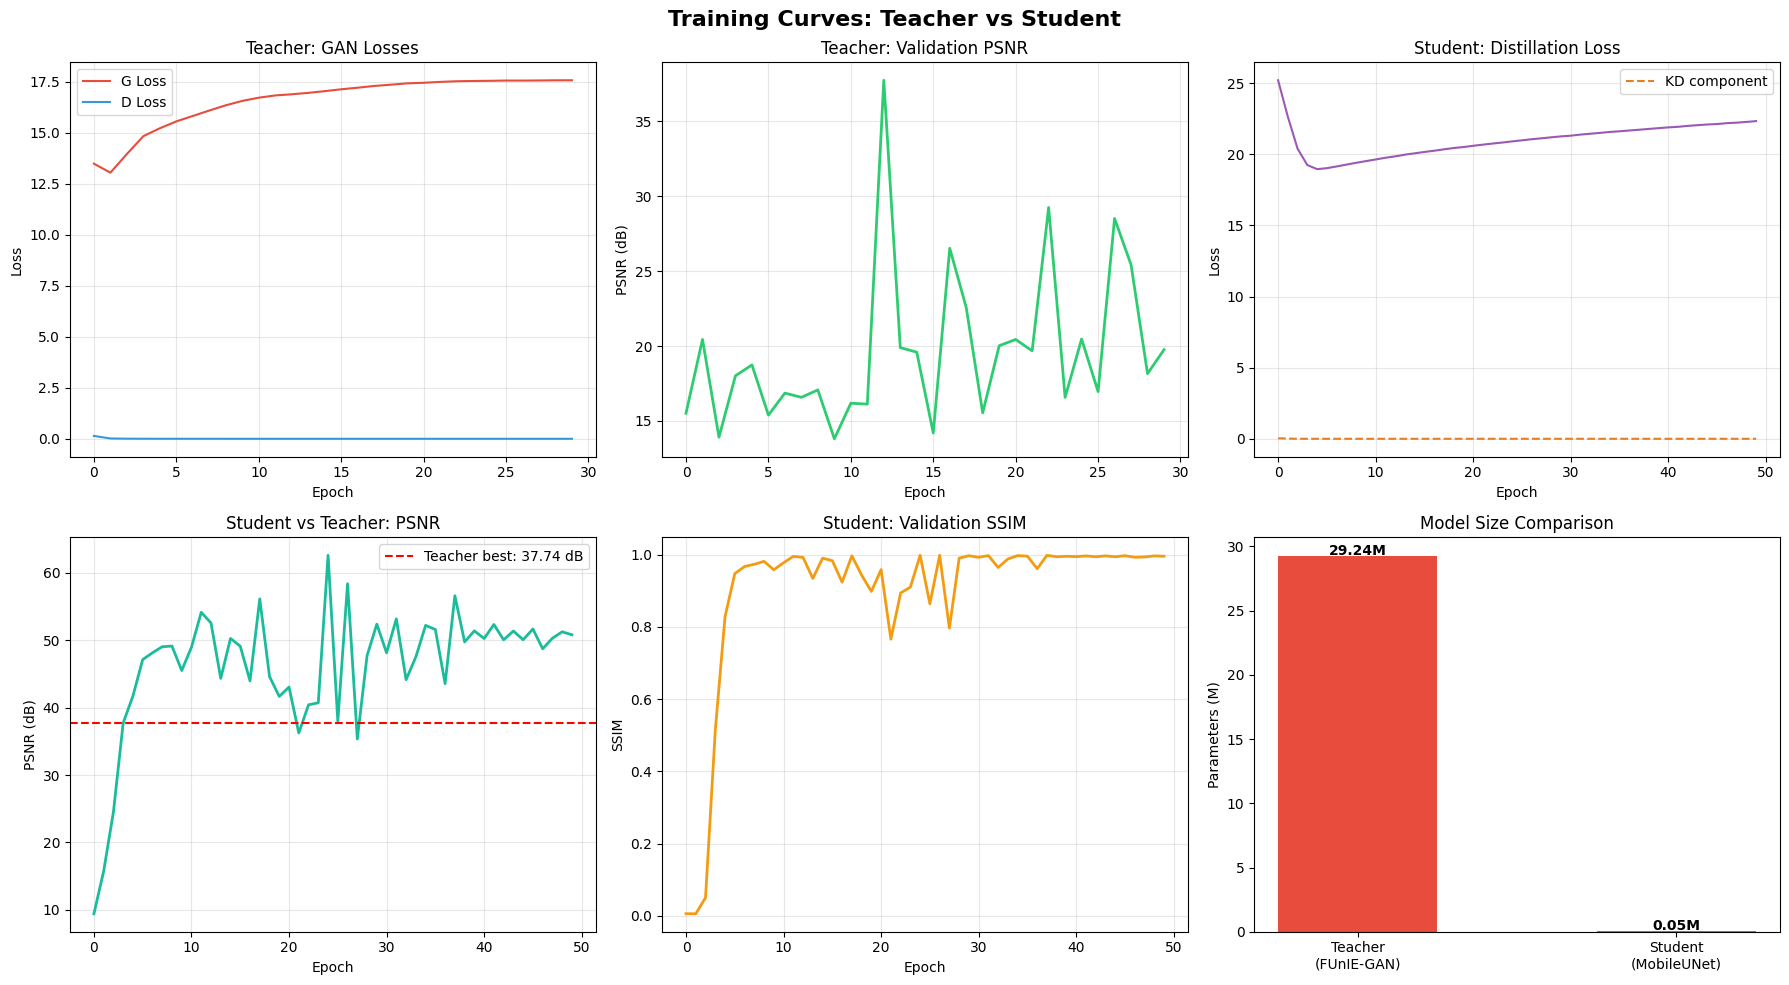

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves: Teacher vs Student', fontsize=16, fontweight='bold')

# Teacher losses
axes[0,0].plot(history_teacher['g_loss'], label='G Loss', color='#E74C3C')
axes[0,0].plot(history_teacher['d_loss'], label='D Loss', color='#3498DB')
axes[0,0].set_title('Teacher: GAN Losses'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')

# Teacher PSNR
axes[0,1].plot(history_teacher['val_psnr'], color='#2ECC71', linewidth=2)
axes[0,1].set_title('Teacher: Validation PSNR'); axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('PSNR (dB)')

# Student total loss
axes[0,2].plot(history_student['total_loss'], color='#9B59B6')
axes[0,2].plot(history_student['kd_loss'], color='#E67E22', linestyle='--', label='KD component')
axes[0,2].set_title('Student: Distillation Loss'); axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)
axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Loss')

# Student PSNR
axes[1,0].plot(history_student['val_psnr'], color='#1ABC9C', linewidth=2)
axes[1,0].axhline(max(history_teacher['val_psnr']), color='red',
                  linestyle='--', label=f'Teacher best: {max(history_teacher["val_psnr"]):.2f} dB')
axes[1,0].set_title('Student vs Teacher: PSNR'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('PSNR (dB)')

# Student SSIM
axes[1,1].plot(history_student['val_ssim'], color='#F39C12', linewidth=2)
axes[1,1].set_title('Student: Validation SSIM'); axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('SSIM')

# Model size comparison
models_name = ['Teacher\n(FUnIE-GAN)', 'Student\n(MobileUNet)']
params_count = [params_G, params_S]
bars = axes[1,2].bar(models_name, params_count, color=['#E74C3C', '#3498DB'], width=0.5)
axes[1,2].set_title('Model Size Comparison'); axes[1,2].set_ylabel('Parameters (M)')
for bar, val in zip(bars, params_count):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{val:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11: UIQM — Underwater Image Quality Measure

In [11]:
def compute_uiqm(img_np):
    """
    UIQM: Underwater Image Quality Measure
    (Panetta et al., 2016)
    UIQM = c1*UICM + c2*UISM + c3*UIConM
    """
    c1, c2, c3 = 0.0282, 0.2953, 3.5753

    # Convert ke float [0,1]
    img = img_np.astype(np.float32) / 255.0
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    # UICM: chroma measure
    rg = r - g
    yb = 0.5*(r + g) - b
    uicm = -0.0268*np.sqrt(rg.var() + yb.var()) + 0.1586*np.sqrt(rg.mean()**2 + yb.mean()**2)

    # UISM: sharpness measure (Sobel gradient)
    from scipy import ndimage
    gray = 0.299*r + 0.587*g + 0.114*b
    gx = ndimage.sobel(gray, axis=1)
    gy = ndimage.sobel(gray, axis=0)
    grad = np.sqrt(gx**2 + gy**2)
    uism = np.mean(grad)

    # UIConM: contrast measure (log-AME)
    eps = 1e-8
    uiconm = np.log(gray.mean() + eps) - np.mean(np.log(np.abs(gray - gray.mean()) + eps))

    return c1*uicm + c2*uism + c3*uiconm


print('UIQM function ready.')

UIQM function ready.


## Cell 12: Full Evaluation on Test Set

In [12]:
def benchmark_speed(model, n_runs=100, img_size=256):
    """Ukur FPS model."""
    dummy = torch.randn(1, 3, img_size, img_size).to(DEVICE)
    # Warmup
    for _ in range(10):
        with torch.no_grad(): model(dummy)
    # Benchmark
    torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
    start = time.time()
    for _ in range(n_runs):
        with torch.no_grad(): model(dummy)
    torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
    elapsed = time.time() - start
    return n_runs / elapsed


def evaluate_model(model, loader, name='Model'):
    model.eval()
    psnrs, ssims, uiqms_in, uiqms_out = [], [], [], []

    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            pred = model(inp)

            # De-normalize
            p_np = (pred[0] * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)
            t_np = (tgt[0]  * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)
            i_np = (inp[0]  * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)

            psnrs.append(psnr(t_np, p_np, data_range=1.0))
            ssims.append(ssim(t_np, p_np, channel_axis=2, data_range=1.0))
            uiqms_in.append(compute_uiqm((i_np * 255).astype(np.uint8)))
            uiqms_out.append(compute_uiqm((p_np * 255).astype(np.uint8)))

    fps = benchmark_speed(model)

    results = {
        'name'    : name,
        'psnr'    : np.mean(psnrs),
        'ssim'    : np.mean(ssims),
        'uiqm_in' : np.mean(uiqms_in),
        'uiqm_out': np.mean(uiqms_out),
        'fps'     : fps,
        'params_M': sum(p.numel() for p in model.parameters()) / 1e6
    }
    return results


print('Evaluating Teacher...')
res_teacher = evaluate_model(teacher_G, test_loader, 'FUnIE-GAN (Teacher)')
print('Evaluating Student...')
res_student = evaluate_model(student, test_loader, 'MobileUNet (Student)')

# Print comparison table
print('\n' + '='*65)
print(f'{"Metric":<20} {"Teacher":>18} {"Student":>18}')
print('-'*65)
metrics = [
    ('PSNR (dB)', 'psnr', '{:.2f}'),
    ('SSIM', 'ssim', '{:.4f}'),
    ('UIQM (input)', 'uiqm_in', '{:.4f}'),
    ('UIQM (output)', 'uiqm_out', '{:.4f}'),
    ('FPS', 'fps', '{:.1f}'),
    ('Params (M)', 'params_M', '{:.2f}'),
]
for label, key, fmt in metrics:
    vt = fmt.format(res_teacher[key])
    vs = fmt.format(res_student[key])
    print(f'{label:<20} {vt:>18} {vs:>18}')
print('='*65)
print(f'\nCompression: {res_teacher["params_M"]/res_student["params_M"]:.1f}x fewer params')
print(f'Speedup: {res_student["fps"]/res_teacher["fps"]:.1f}x faster FPS')

Evaluating Teacher...
Evaluating Student...

Metric                          Teacher            Student
-----------------------------------------------------------------
PSNR (dB)                         33.01              62.24
SSIM                             0.8273             0.9945
UIQM (input)                    -0.1077            -0.1077
UIQM (output)                   -0.1857            -0.0521
FPS                               163.0              479.1
Params (M)                        29.24               0.05

Compression: 642.3x fewer params
Speedup: 2.9x faster FPS


## Cell 13: Visualisasi Before vs After (Highlight Utama)

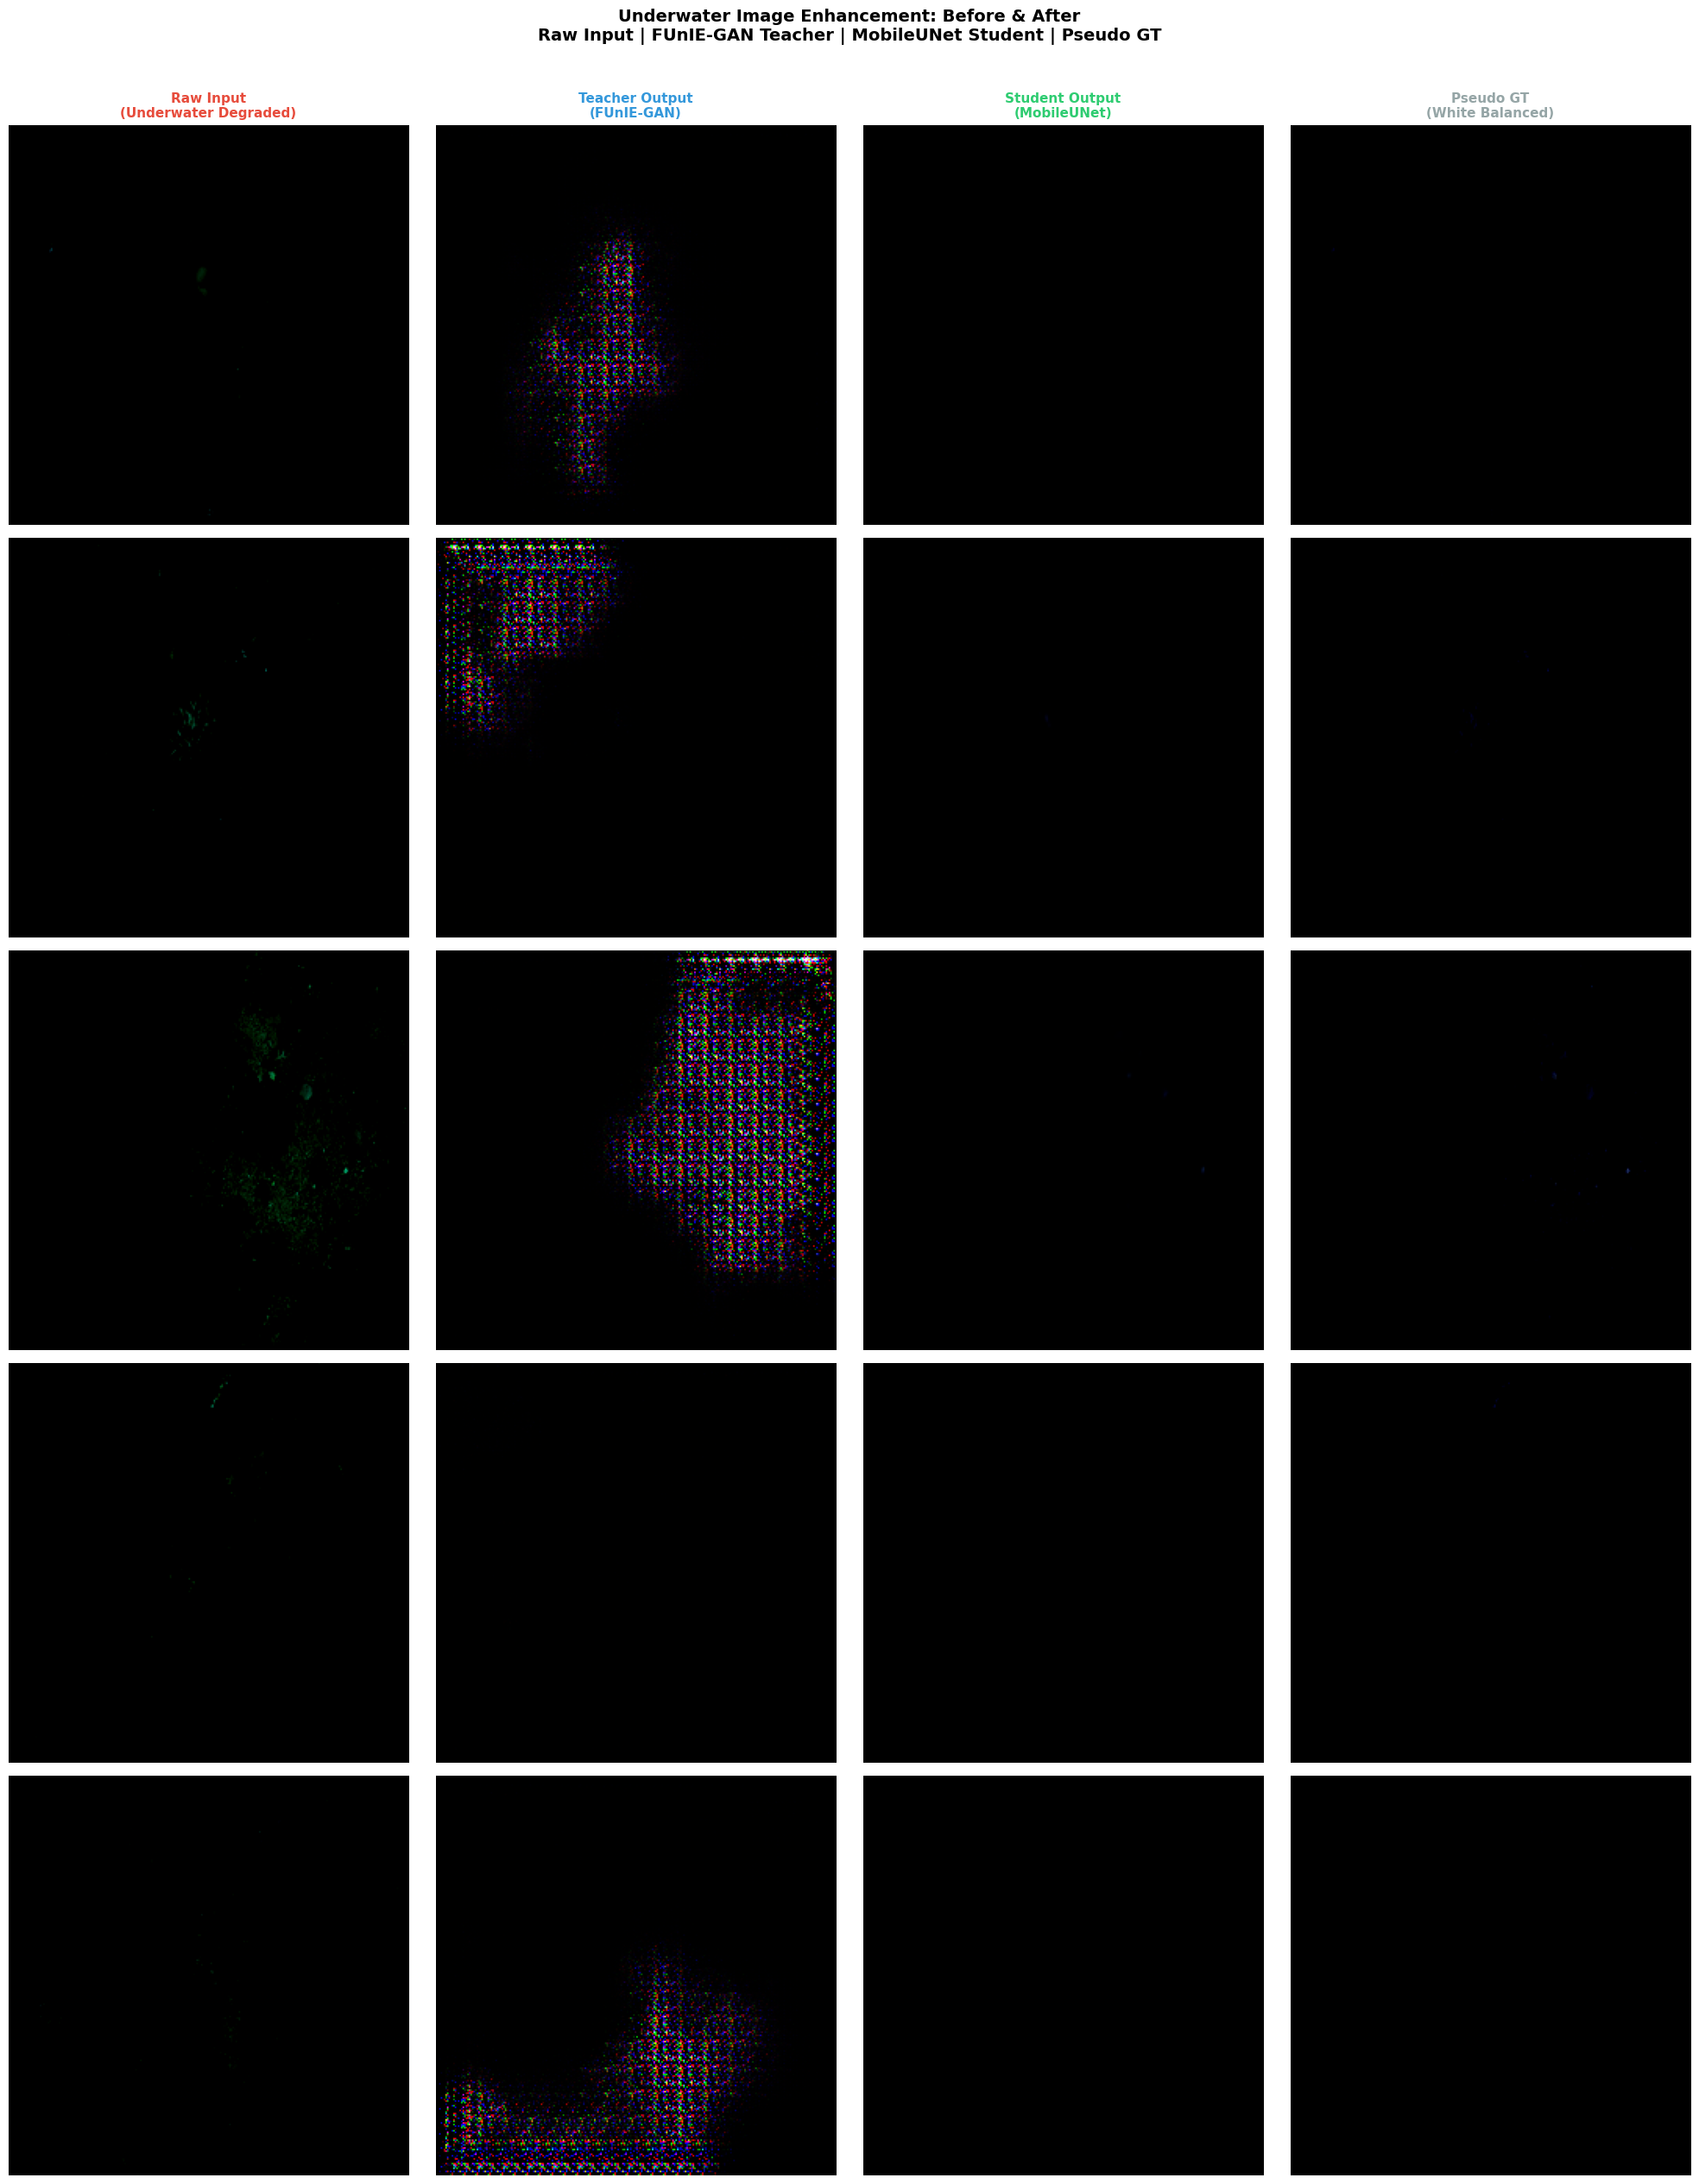

Saved: before_after_comparison.png


In [13]:
def visualize_results(model_teacher, model_student, test_ds, n_samples=5):
    """
    Visualisasi perbandingan:
    Kolom: Raw Input | Teacher Output | Student Output | Pseudo GT
    """
    indices = random.sample(range(len(test_ds)), n_samples)
    fig, axes = plt.subplots(n_samples, 4, figsize=(20, 5 * n_samples))
    fig.suptitle(
        'Underwater Image Enhancement: Before & After\n'
        'Raw Input | FUnIE-GAN Teacher | MobileUNet Student | Pseudo GT',
        fontsize=14, fontweight='bold', y=1.01
    )

    col_titles = ['Raw Input\n(Underwater Degraded)',
                  'Teacher Output\n(FUnIE-GAN)',
                  'Student Output\n(MobileUNet)',
                  'Pseudo GT\n(White Balanced)']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold',
                               color=['#E74C3C','#3498DB','#2ECC71','#95A5A6'][col])

    for row, idx in enumerate(indices):
        inp, tgt = test_ds[idx]
        inp_b = inp.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            t_out = model_teacher(inp_b)
            s_out = model_student(inp_b)

        def to_img(t):
            return (t.squeeze(0) * 0.5 + 0.5).clamp(0, 1).cpu().numpy().transpose(1,2,0)

        imgs = [
            (inp * 0.5 + 0.5).clamp(0,1).numpy().transpose(1,2,0),
            to_img(t_out),
            to_img(s_out),
            (tgt * 0.5 + 0.5).clamp(0,1).numpy().transpose(1,2,0)
        ]

        psnr_t = psnr(imgs[3], imgs[1], data_range=1.0)
        psnr_s = psnr(imgs[3], imgs[2], data_range=1.0)
        ssim_t = ssim(imgs[3], imgs[1], channel_axis=2, data_range=1.0)
        ssim_s = ssim(imgs[3], imgs[2], channel_axis=2, data_range=1.0)

        for col, img in enumerate(imgs):
            axes[row, col].imshow(np.clip(img, 0, 1))
            axes[row, col].axis('off')
            if col == 1:
                axes[row, col].set_xlabel(f'PSNR: {psnr_t:.2f} | SSIM: {ssim_t:.4f}',
                                          fontsize=9, labelpad=3)
            if col == 2:
                axes[row, col].set_xlabel(f'PSNR: {psnr_s:.2f} | SSIM: {ssim_s:.4f}',
                                          fontsize=9, labelpad=3)

    plt.tight_layout()
    plt.savefig('before_after_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: before_after_comparison.png')


visualize_results(teacher_G, student, test_ds, n_samples=5)

## Cell 14: Radar Chart — Summary Evaluasi

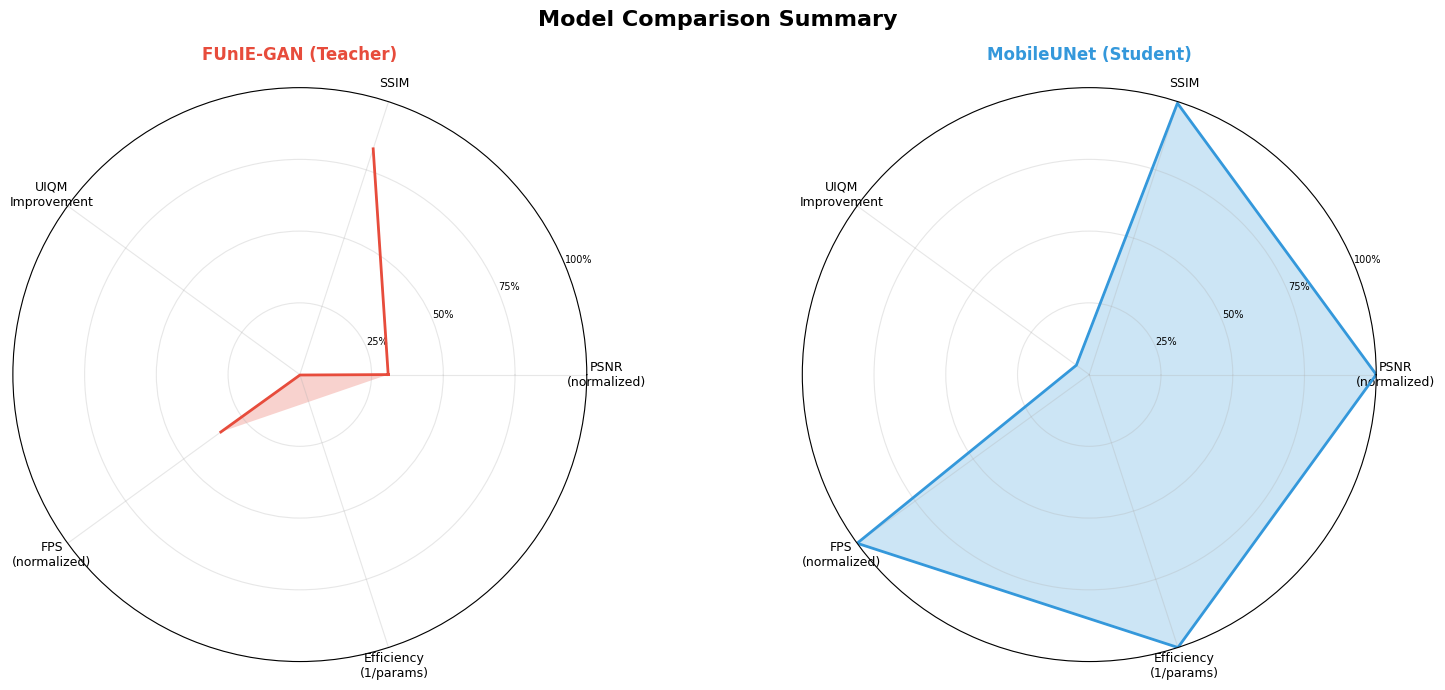


📊 FINAL SUMMARY
                                  Teacher         Student        Δ
-----------------------------------------------------------------
PSNR (dB)                           33.01           62.24 + +29.23
SSIM                               0.8273          0.9945 +  +0.17
UIQM (output)                     -0.1857         -0.0521 +  +0.13
FPS                                 163.0           479.1 ++316.04
Parameters (M)                      29.24            0.05  -29.20


In [14]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# ── Radar Chart ──
categories = ['PSNR\n(normalized)', 'SSIM', 'UIQM\nImprovement', 'FPS\n(normalized)', 'Efficiency\n(1/params)']
N = len(categories)

def normalize_metric(val, low, high):
    return (val - low) / (high - low + 1e-8)

fps_max = max(res_teacher['fps'], res_student['fps'])
psnr_max = max(res_teacher['psnr'], res_student['psnr'])

teacher_vals = [
    normalize_metric(res_teacher['psnr'], 20, psnr_max),
    res_teacher['ssim'],
    normalize_metric(res_teacher['uiqm_out'] - res_teacher['uiqm_in'], 0, 1),
    normalize_metric(res_teacher['fps'], 0, fps_max),
    normalize_metric(1/res_teacher['params_M'], 0, 1/res_student['params_M'])
]
student_vals = [
    normalize_metric(res_student['psnr'], 20, psnr_max),
    res_student['ssim'],
    normalize_metric(res_student['uiqm_out'] - res_student['uiqm_in'], 0, 1),
    normalize_metric(res_student['fps'], 0, fps_max),
    normalize_metric(1/res_student['params_M'], 0, 1/res_student['params_M'])
]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # tutup lingkaran
teacher_vals += teacher_vals[:1]
student_vals  += student_vals[:1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                subplot_kw=dict(projection='polar'))
fig.suptitle('Model Comparison Summary', fontsize=16, fontweight='bold')

for ax, vals, name, color in [
    (ax1, teacher_vals, 'FUnIE-GAN (Teacher)', '#E74C3C'),
    (ax2, student_vals, 'MobileUNet (Student)', '#3498DB')
]:
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=12, fontweight='bold', pad=20, color=color)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ──
print('\n📊 FINAL SUMMARY')
print('='*65)
print(f'{"":<25} {"Teacher":>15} {"Student":>15} {"Δ":>8}')
print('-'*65)
rows = [
    ('PSNR (dB)', 'psnr', '{:.2f}', True),
    ('SSIM', 'ssim', '{:.4f}', True),
    ('UIQM (output)', 'uiqm_out', '{:.4f}', True),
    ('FPS', 'fps', '{:.1f}', True),
    ('Parameters (M)', 'params_M', '{:.2f}', False),
]
for label, key, fmt, higher_better in rows:
    vt = res_teacher[key]; vs = res_student[key]
    diff = vs - vt
    sign = '+' if diff >= 0 else ''
    print(f'{label:<25} {fmt.format(vt):>15} {fmt.format(vs):>15} {sign}{diff:>+7.2f}')
print('='*65)

## Cell 15: Save Model & Export

Simpan model untuk deployment.

In [15]:
# Save full checkpoint
torch.save({
    'student_state_dict': student.state_dict(),
    'teacher_state_dict': teacher_G.state_dict(),
    'student_psnr': best_student_psnr,
    'teacher_psnr': best_val_psnr,
    'config': {'img_size': IMG_SIZE, 'seed': SEED}
}, '/kaggle/working/underwater_enhancement_checkpoint.pth')

# Export Student ke ONNX (untuk deployment Raspberry Pi / Micro-AUV)
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
student.eval()
torch.onnx.export(
    student, dummy_input,
    '/kaggle/working/student_mobileunet.onnx',
    opset_version=11,
    input_names=['input'],
    output_names=['enhanced'],
    dynamic_axes={'input': {0: 'batch_size'}, 'enhanced': {0: 'batch_size'}}
)

import os
onnx_size = os.path.getsize('/kaggle/working/student_mobileunet.onnx') / 1e6
print(f'Checkpoint saved: underwater_enhancement_checkpoint.pth')
print(f'ONNX exported: student_mobileunet.onnx ({onnx_size:.1f} MB)')
print(f'\nStudent model size: {params_S:.2f}M params')
print(f'Ready for deployment on edge devices!')

ModuleNotFoundError: No module named 'onnxscript'